# Objetivo: que toda la difusion vaya junta, y que cambiando las clases cambiemos soii es mnist o de audios o stable

In [1]:
%run init_notebook.py

import torch.nn as nn
from torchvision.datasets import FashionMNIST, QMNIST, KMNIST
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import time

import torchaudio.transforms as T
from src.dataset import NSynth
import torch
from src.diffusion import *
from src.utils.models import adjust_shape, compute_magnitude_and_phase, compute_magnitude_and_phase_sin_cos

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

root = r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion"
paths = {
    'minst' : {
        'model': root + r"\minst\model.pth",
        'object': root + r"\minst\object.pth",
        'scheduler': root + r"\minst\scheduler.pth",
        'checkpoint': root + r"\minst\checkpoint.pth",
        'dataset' : r"C:\Users\Articuno\Desktop\TFG-info\data\mnist"
    },
    'audio' : {
        'model': root + r"\audio\model.pth",
        'object': root + r"\audio\object.pth",
        'scheduler': root + r"\audio\scheduler.pth",
        'checkpoint': root + r"\audio\checkpoint.pth"
    },
    'stable' : {
        'model': root + r"\stable\model.pth",
        'object': root + r"\stable\object.pth",
        'scheduler': root + r"\stable\scheduler.pth",
        'checkpoint': root + r"\stable\checkpoint.pth",
    }
}

In [2]:
def save_checkpoint(model, optimizer, epoch, loss, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, path)

def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path, map_location='cpu')  # o 'cuda' si usas GPU
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    
    return model, optimizer, epoch, loss

def train(
    model, 
    transform_data=None,
    epochs=100, 
    batch_size=16, 
    lr=1e-3, 
    modality='audio',
    dataset=NSynth('training'), 
    verbose=False,
    verbose_batchs=0,
):
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    scheduler = Scheduler(num_epochs=epochs).to(device)
    diffuser = Diffuser(model, scheduler).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)    
    scaler = torch.cuda.amp.GradScaler()
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)


    mse_loss = nn.MSELoss()
    best_loss = 1
    losses = []
        
    for epoch in range(epochs):
        start_time = time.time() 
        _d_batch_index = 0
        epoch_loss = 0
        for x in train_loader:
            _d_batch_index += 1
            # wave = wave.to(device)
            # x = stft_transform(wave)
            if transform_data is not None:
                x = transform_data(x)
            x = x.to(device)                
            batch_size = x.size(0)
            t = torch.randint(0, epochs, (batch_size,), device=device, dtype=torch.long)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(dtype=torch.bfloat16): # OPTIMIZACION FLOAT 32
                # print(f"mag: {mag.shape}, sin: {sin.shape}, cos: {cos.shape}, x: {x.shape}")
                z, e = diffuser(x, t)
                e_pred = model(z, t)
                if e_pred.shape != e.shape: # TODO borrar esto es debug
                    print('error en los tamaños')

                loss = mse_loss(e_pred, e)
                epoch_loss += loss.item()

            scaler.scale(loss).backward() # TODO no se si la funcion de loss es la mas optima para el caso
            scaler.step(optimizer)

            scaler.update()
            
            if verbose_batchs != 0:
                if _d_batch_index % verbose_batchs == 0:
                    _t = time.time() - start_time
                    print(f'tiempo en {_d_batch_index} batchs: {_t:.5f} \t| media de tiempo por batch: {_t/_d_batch_index:.5f} \t| media de loss: {epoch_loss/_d_batch_index:.5f}')

        losses.append(epoch_loss/_d_batch_index)
        lr_scheduler.step() # LEARNING SCHEDULER

            
        if verbose:
            _t = time.time() - start_time
            print(f"Epoch {epoch}, Loss: {loss.item()}, time: {time.time() - start_time}, avg wave time: {_t/(batch_size*_d_batch_index)}")
            
        if loss.item() < best_loss:
            best_loss = loss.item()
            
            if modality:
                save_checkpoint(model, optimizer, epoch, loss.item(), paths[modality]['checkpoint'])
            
    
    # AL FINALIZAR EL ENTRENAMIENTO, GUARDAMOS EL MODELO Y EL SCHEDULER
    if modality:
        torch.save(model.state_dict(), paths[modality]['model'])
        torch.save(scheduler.state_dict(), paths[modality]['scheduler'])
        torch.save(model, paths[modality]['object'])
        
    print("Training completed., best loss:", best_loss)
    
    return model, scheduler, losses
    

## MINST

In [3]:
def MINST_transform(x):
    img, _ = x
    return img

In [4]:
def train_MINST(epochs=10, learning_rate=1e-4, batch_div=1, channels_div=1): # MODEL SETUP

    ## Training setup
    batch_size = 2048//batch_div

    ## Image Size
    input_height = 28
    input_width = 28

    input_size = (input_height, input_width)
    emb_dim = 128
    norm_groups = 8

    # LAYERS
    sin = sout = c = 128//channels_div  # canal base, reducido para no explotar memoria

    down_layers = [  
        DummyLayer(c,    c*2,  norm_groups, emb_dim, skip=True, stride=1).to(device),  # skip: c canales
        DummyLayer(c*2,  c*4,  norm_groups, emb_dim, skip=False, stride=1).to(device),  # skip: c*2 canales
        DummyLayer(c*4,  c*8,  norm_groups, emb_dim, skip=False, stride=1).to(device),  # skip: c*4 canales
        # DummyLayer(c*8,  c*16, norm_groups, emb_dim, skip=True, stride=2).to(device),  # skip: c*8 canales
    ]

    bottleneck = DummyLayer(c*8, c*8, norm_groups, emb_dim).to(device)

    up_layers = [
        # DummyLayer(c*16 + c*8,  c*8, norm_groups, emb_dim, stride=-2).to(device),
        DummyLayer(c*8,  c*4, norm_groups, emb_dim, stride=-1).to(device),
        DummyLayer(c*4,  c*2, norm_groups, emb_dim, stride=-1).to(device),
        DummyLayer(c*2 + c,    c,   norm_groups, emb_dim, stride=-1).to(device),
    ]

    # EMBEDDER
    embedder = Embedder(num_epochs=epochs, embed_dim=emb_dim).to(device)

    # SCHEDULER
    scheduler = Scheduler(num_epochs=epochs).to(device)

    # MODEL
    model = DiffusionModel(
        layer_channels=(sin, sout),
        norm_groups=norm_groups,
        up_layers=up_layers,
        down_layers=down_layers,
        bottleneck=bottleneck,
        embedder=embedder, 
        input_channels=1,
        output_channels=1,
    ).to(device)

    # %%time
    model, scheduler, losses = train(
        model, 
        transform_data=MINST_transform,
        epochs=epochs,
        batch_size=batch_size, 
        lr=learning_rate, 
        modality='minst',
        dataset= QMNIST(root=paths['minst']['dataset'], train=True,  download=True, transform=ToTensor()),
        verbose=True,
        verbose_batchs=0,
    )
    plt.plot(losses)
    print(f'learning_rate: {learning_rate}')
    print(f'num_chaneles (c) {c}')
    
    return model, scheduler, losses


## AUDIO

In [5]:
class AudioPipeline:
    def __init__(self, stft_transform):
        self.stft_transform = stft_transform

def pipeline_audio(self, x):
    wave, _, _, _ = x # solo nos quedamos con la onda, el resto no nos interesa
    stft_spec = self.stft_transform(wave)
    log_mag, sin, cos = compute_magnitude_and_phase_sin_cos(stft_spec) ## SINCOS
    x = torch.cat([log_mag, sin, cos], dim=1).to(device)  ## SINCOS

In [6]:
def train_audio(epochs=10, learning_rate=1e-4, batch_div=1, channels_div=1):
    # STFT transform
    sample_rate = 16000
    n_fft = 1500 # DISMINUIR TAMAÑO PARA OPTIMIZAR
    hop_length = 250
    win_length = n_fft

    stft_transform = T.Spectrogram(
        n_fft=n_fft, win_length=win_length, hop_length=hop_length,
        power=None, onesided=False, center=False
    ).to(device)
    istft_transform = T.InverseSpectrogram(
        n_fft=n_fft, win_length=win_length, hop_length=hop_length, onesided=False
    ).to(device)

    transform_audio = AudioPipeline(stft_transform)

    # TRAIN SETUP
    batch_size = 32//batch_div
    learning_rate = 1e-4
    epochs = 20
    # train_loader = DataLoader(NSynth('training'), batch_size=batch_size, shuffle=True, pin_memory=True)
    # valid_loader = DataLoader(NSynth('validation'), batch_size=batch_size, shuffle=True, pin_memory=True)

    # MODEL SETUP
    input_height = 1500
    input_width = 251
    input_size = (input_height, input_width)
    emb_dim = 128
    norm_groups = 6


    # layers
    sin = sout = c = 12//channels_div  # canal base, reducido para no explotar memoria
    # TODO hacer que el tamaño dependa de n_ftt
    down_layers = [  
        DummyLayer(c,    c*2,  norm_groups, emb_dim, skip=True, stride=1).to(device),  # skip: c canales
        DummyLayer(c*2,  c*4,  norm_groups, emb_dim, skip=True, stride=1).to(device),  # skip: c*2 canales
    ]

    bottleneck = DummyLayer(c*4, c*4, norm_groups, emb_dim).to(device)

    up_layers = [ # TODO Podria hacer esto con stride = -2? o coger y hacer que si el stride es negativo, aumente manualmente 
        DummyLayer(c*4 + c*4, c*2, norm_groups, emb_dim, stride=1).to(device),
        DummyLayer(c*2 + c*2, c, norm_groups, emb_dim, stride=1).to(device),
    ]

    # Embedder
    embedder = Embedder(num_epochs=epochs, embed_dim=emb_dim).to(device)

    # scheduler
    scheduler = Scheduler(num_epochs=epochs).to(device)

    # model
    model = DiffusionModel(
        layer_channels=(sin, sout),
        norm_groups=norm_groups,
        up_layers=up_layers,
        down_layers=down_layers,
        bottleneck=bottleneck,
        embedder=embedder, 
        input_channels=3, ##SINCOS
        output_channels=3, ##SINCOS
    ).to(device)

    model, scheduler, losses = train(
        model, 
        transform_data=transform_audio.stft_transform,
        epochs=epochs,
        batch_size=batch_size, 
        lr=learning_rate, 
        modality='audio',
        dataset=NSynth('training'),
        verbose=True,
        verbose_batchs=100,
    )
    plt.plot(losses)
    print(f'learning_rate: {learning_rate}')
    print(f'num_chaneles (c) {c}')
    return model, scheduler, losses

# TRAININGS

Epoch 0, Loss: 0.2709295451641083, time: 23.288180589675903, avg wave time: 0.0010322775084076199
Epoch 1, Loss: 0.19158734381198883, time: 22.68820595741272, avg wave time: 0.001005682888183188
Epoch 2, Loss: 0.17349228262901306, time: 22.797815561294556, avg wave time: 0.0010105414699155388
Epoch 3, Loss: 0.15872882306575775, time: 22.78812050819397, avg wave time: 0.001010111724653988
Epoch 4, Loss: 0.13973744213581085, time: 22.921579837799072, avg wave time: 0.001016027475079746
Epoch 5, Loss: 0.13521519303321838, time: 22.92930030822754, avg wave time: 0.001016369694513632
Epoch 6, Loss: 0.15162178874015808, time: 22.832258701324463, avg wave time: 0.0010120682048459426
Epoch 7, Loss: 0.16601353883743286, time: 22.948872804641724, avg wave time: 0.0010172372697092962
Epoch 8, Loss: 0.13476932048797607, time: 22.89094114303589, avg wave time: 0.0010146693769076192
Epoch 9, Loss: 0.1321018785238266, time: 22.903881311416626, avg wave time: 0.001015242965931588
Epoch 10, Loss: 0.134

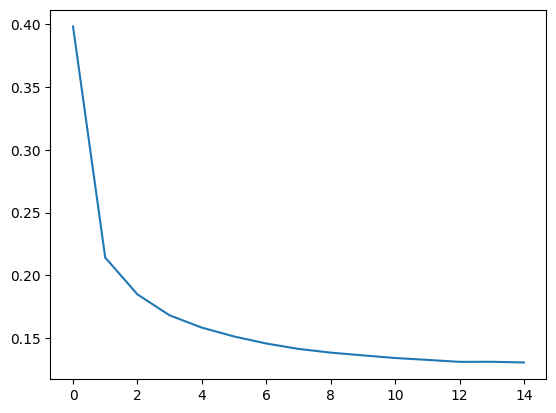

In [7]:
model, scheduler, losses = train_MINST(epochs=15, batch_div=8, channels_div=4)

In [8]:
# TODO 
# dividir la funcion train_XX en load_model y train, de esta forma lo mismo se puede seguir entrenando
# guardar el lr scheduler
# añadir el stable
# añadir para mostrar imagenes y samplear y eso

# MODEL FROM MEM

# SAMPLING

In [9]:
def sample_raw_img(model, schdeuler, image_size=(1, 28, 28), num_images=1):
    model.eval() # NS
    x = torch.randn(n, *image_size, device=device) # imagen de ruidio inicial
    T = scheduler.beta.size(0)
    
    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar
    
    for t in reversed(range(T)):
        t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)

        # predicción de ruido
        e_pred = model(x, t_batch)
        
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        
        # beta_t = beta_t.view(1,1,1,1)
        # alpha_t = alpha_t.view(1,1,1,1)
        # alpha_bar_t = alpha_bar_t.view(1,1,1,1)


        # Coeficientes DDPM
        coef1 = 1 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

        mu = coef1 * (x - coef2 * e_pred)

        if t > 0:
            noise = torch.randn_like(x)
            sigma_t = torch.sqrt(beta_t)
            x = mu + sigma_t * noise
        else:
            x = mu

    x = x.clamp(0, 1).cpu()
    
    return x
    

mostrar las imagenes raw del modelo

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

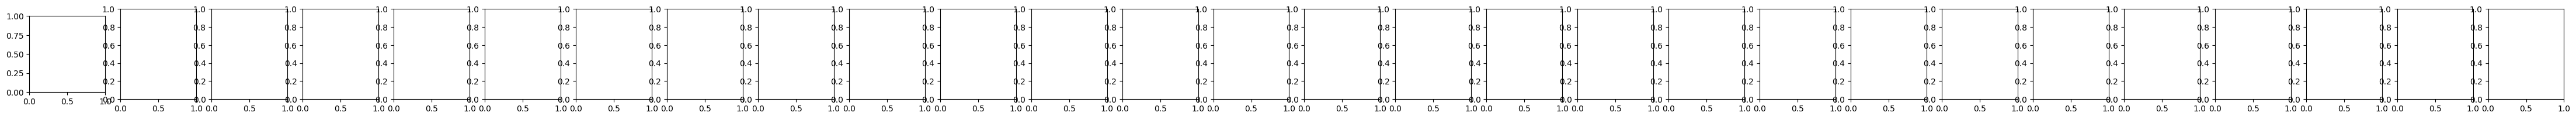

In [10]:
n = 28

x = sample_raw_img(model, scheduler, (1, 28, 28), n)
# Mostrar imágenes
fig, axes = plt.subplots(1, n, figsize=(n*2, 2))
for i in range(n):
    axes[i].imshow(x[i, 0], cmap='gray')
    axes[i].axis('off')
plt.show()

